PREDICTING STARTUP SURVIVAL: A MACHINE LEARNING PERSPECTIVE
 
> In questa tesi vengono combinate tecniche di Data Mining e Machine Learning
con l’obiettivo di identificare i principali fattori di rischio per le startup (con un
particolare focus su Competitors, Team e Funding), in modo da prevederne l’eventuale fallimento.

> I dati presi in esame provengono dalla piattaforma PitchBook, e
sono stati elaborati in linea con la letteratura economica recente.

> A partire dalle metriche calcolate, sono stati addestrati diversi modelli (Alberi
Decisionali, Random Forest, Reti Neurali Artificiali), i quali sono stati successivamente valutati in base alla capacità di classificare correttamente le startup fallite.
Questi esperimenti hanno permesso, inoltre, di cogliere i principali indicatori di "sopravvivenza" delle startup, mediante il valore dell’importanza che ogni modello
assegna a una determinata feature. Un ulteriore studio è stato svolto tramite l’impiego del Random Survival Forest, una versione alternativa del Random Forest
ideata per l’analisi della sopravvivenza.

In [3]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import polars as pl
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report

from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight
import os
from dotenv import load_dotenv 


import yaml

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from src.preprocessing import processUniversityList, getFlagTop50Institute,lump_categories

import matplotlib.pyplot as plt # Necessario per salvare i grafici
import seaborn as sns


from src.models.MLP import MLP

import scipy.integrate
if not hasattr(np, 'trapz'):
    np.trapz = scipy.integrate.trapezoid

load_dotenv()

with open('config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Lettura della versione iniziale del dataset "master" 

In [4]:
df = pl.read_csv(config['paths']['raw_dataset'],null_values=["NA"])

# Sostituisco "Stay" con il valore attuale di "GrowthStageGroup"
df = df.with_columns(
    pl.when(pl.col("GrowthNextStageGroup") == "Stay")
    .then(pl.col("GrowthStageGroup"))
    .otherwise(pl.col("GrowthNextStageGroup"))
    .alias("GrowthNextStageGroup")
)

Pre-processing
Il dataset di partenza è un panel in cui ogni azienda presenta un record per ogni anno di vita disponibile.
Nell' ottica di sperimentare con modelli di classificazione, si è scelto di focalizzarsi sui dati delle aziende che si trovano in fase di Early per provare a prevederne la condizione al qT-esimo anno successivo. Per fare ciò, il dataset viene raggruppato per azienda, mantenendo i valori delle features all'entrata nella fase Early; la variabile target viene invece mantenuta al T-esimo anno successivo o all'ultimo dato disponibile.   

Per evitare troppa diversità tra le aziende sono stati applicati alcuni filtri:
 - Il valore di Age all'entrata della fase Early deve essere <=2 (è così per la maggior parte delle aziende a parte alcuni outliers che vengono così eliminati)
 - L'anno di fondazione deve essere compreso tra il 2010 e il 2024-T (i dati si fermano al 2024)


In [5]:
T=7

lastYear=2024-T

df_preseed = df.filter(
    pl.col("GrowthStageGroup")
    .eq("Early")
    .any()
    .over("CompanyID")
)
df_preseed=df_preseed.drop_nulls(subset=['GrowthStageGroup'])


df_preseed = df_preseed.select(["CompanyID", "Age"])

# aggregazioni per azienda
df_combined = (
    df_preseed
    .group_by("CompanyID")
    .agg([
        pl.col("Age").min().alias("StartingAge"),
        pl.col("Age").max().alias("LastAge"),
    ])
    .with_columns(
        pl.min_horizontal(
            pl.col("StartingAge") + T,
            pl.col("LastAge")
        ).alias("TargetAge")
    )
    .filter(pl.col("StartingAge") <= 2) # filtro aggiunto per evitare valori troppo diversi (in ogni caso la maggior parte delle aziende aveva un Age compreso tra 0 e 2 al momento dell'entrata in preseed)
)

df = df.join(df_combined, on="CompanyID")


df_target = df.filter(
    pl.col("Age") == pl.col("TargetAge")
).select(["CompanyID", "StartingAge" ,"TargetAge" ,'GrowthStageGroup','TimeNextStageGroup','GrowthNextStageGroup'])


df_target = df_target.with_columns(
    pl.when(pl.col("TargetAge") + pl.col("TimeNextStageGroup")<=pl.col("StartingAge") + 5) 
    .then(pl.col("GrowthNextStageGroup"))
    .otherwise(pl.col("GrowthStageGroup"))
    .alias("Target")
)

df_target_panel=df.join(df_target.select(["CompanyID", "Target"]),on='CompanyID')


df_target_final = df_target_panel.filter(
    (pl.col("Age") == pl.col("StartingAge")) &
    (pl.col("YearFounded") <= lastYear) &
    (pl.col("YearFounded") >= 2010)
)




Feature selection

In [6]:
df_target_final=df_target_final.select(['CompanyID', 'Target' ,'YearFounded','Age', 'N_Deal', 'TotalRaised_Est', 
                                        'Percent_Females', 'Is_Eco', 'Is_Eng', 'Is_NS', 
                                        'Is_Hum', 'Is_SS', 'Is_Med', 'Is_Law', 'Is_IT', 
                                         'Institute', 'WorkExp_Idx_Mean', 'Total_Founders', 'Is_Debt', 
                                         'Is_SpinOff', 'Is_CrowdFunding',  
                                        'MeanMedianRoundAmount_cum', 'Is_Accelerator', 'has_Corporate', 
                                        'has_VentureCapital', 'has_PublicInvestor', 'has_Angel_Lead', 'has_Corporate_Lead',
                                        'has_VentureCapital_Lead', 'has_Accelerator_Lead', 'has_PrivateEquity_Lead', 'has_PublicInvestor_Lead', 
                                          'HQCountry', 'PrimaryIndustrySector',
                                        'SimilarityScoreMean', 'N_Competitors', 'Same_Country','Highest_Degree_CEO','Gender_CEO','MeanTotalInvestments_cum',
                                        'WorkExperienceIndex_CEO', 'Is_Angel',  'Total_People', 'Is_Grant','has_PrivateEquity','TotalInvestors', 'Highest_Degree_Mean','Avg_Earliest_Year'
                                        ])
                                       
 # 'MeanTotalActivePortfolio_cum'


Viene creata la feature booleana HasTop50Institute che ha valore positivo se almeno una delle Università citate nella colonna 'Institutes' è presente nella classifica delle 50 migliori università al mondo. La classifica è stata stilata da QS World University Rankings ed è contenuta nel file QS_World_Rankings.csv.

Per fare ciò è stato svolto un confronto di stringhe tramite Jaccard Similarity.

In fase di preprocessing e di match sono state utilizzate diverse tecniche di NLP:

> Text Normalization: 
    Prima del confronto, il codice "pulisce" il testo per ridurre la variabilità semantica. Tutto il testo viene convertito in minuscolo. Vengono rimossi caratteri speciali come virgole, trattini e spazi multipli tramite Espressioni Regolari. Il codice rimuove parole comuni che non aiutano a distinguere un'università dall'altra, come "university", "of", "the". In NLP, queste sono considerate "stop words" specifiche del dominio accademico.

> Nella funzione calculate_similarity_by_words, il codice trasforma le stringhe in insiemi di parole: La stringa viene spezzata in singole unità (parole) usando lo spazio come delimitatore (Tokenizzazione). Trasformando la lista in un set(), il codice ignora l'ordine delle parole e le ripetizioni, concentrandosi solo sulla presenza dei termini (Bag of Words).

> Viene implementata una logica di Named Entity Disambiguation basata sugli acronimi: Tramite la Regex r"\((.*?)\)" viene estratto il testo tra parentesi (es. "MIT" da "Massachusetts Institute of Technology (MIT)"). Il confronto avviene su due binari: se l'acronimo combacia, l'istituto è confermato immediatamente, riducendo i falsi negativi dovuti a nomi troppo lunghi o complessi.

> Logica di Matching Ibrida: Il confronto finale non è una semplice uguaglianza, ma un sistema a cascata: Exact Match su Acronimo: Se l'acronimo estratto è presente nella lista Top 50. Exact Match su Stringa Pulita: Se la stringa normalizzata è identica. Substring Matching: Verifica se un acronimo è contenuto all'interno del nome (es: "MIT" in "MIT Boston"). Fuzzy Matching (Soglia): Se la similarità di Jaccard supera il threshold=0.5.

In [7]:
# Caricamento e pulizia università
top_50 = processUniversityList(config['paths']['raw_university_ranking'])

df_target_final=df_target_final.with_columns(pl.col("Institute").map_elements( lambda x: getFlagTop50Institute(x, top_50),return_dtype=pl.Boolean, 
        skip_nulls=False).alias("HasTop50Institute"))

df_target_final=df_target_final.drop("Institute")

counts = df_target_final["HasTop50Institute"].value_counts()



Rimozione nazioni non abbastanza frequenti e frequency encoding della colonna 'HQCountry'

Frequency encoding colonna 'PrimaryIndustryGroup'

In [8]:
df_target_final = lump_categories(df_target_final, "HQCountry", min_count=1000)


#frequency encoding HQCountry
freq_df = df_target_final.group_by("HQCountry").agg(
    pl.len().alias("HQCountryFreq")
)

df_target_final = df_target_final.join(freq_df, on="HQCountry").drop("HQCountry")


#frequency encoding PrimaryIndustrySector

freq_df = df_target_final.group_by("PrimaryIndustrySector").agg(
    pl.len().alias("PrimaryIndustrySectorFreq")
)

df_target_final = df_target_final.join(freq_df, on="PrimaryIndustrySector").drop("PrimaryIndustrySector")


# feature indicatore per il genere del CEO
df_target_final = df_target_final.to_dummies("Gender_CEO").drop("Gender_CEO_Male").drop("Gender_CEO_null")



Gestione Missing Values

Scarto le righe che hanno missing valueas per Total_People, in quanto presentano lo stesso problema per la maggior parte delle features del team

In [9]:
df_target_final = df_target_final.drop_nulls(subset=['Total_People'])


df_target_final = df_target_final.with_columns(
    pl.col(pl.Boolean).cast(pl.Int8)
)

# #Per queste variabili si è deciso di imputare i missing values a 0
variabili_toInt = [ 'N_Competitors','Same_Country'] 

df_target_final = df_target_final.with_columns(
    [pl.col(name).cast(pl.Int64).fill_null(0) for name in variabili_toInt]

)

df_target_final = df_target_final.with_columns(
    pl.col('SimilarityScoreMean').fill_null(pl.col('SimilarityScoreMean').mean()) 

)

#Conversione mantenendo i missing values 
df_target_final = df_target_final.with_columns(
    pl.col(["YearFounded","Age",'Total_Founders','Total_People','Is_Eco','Is_Eng','Is_NS','Is_Hum','Is_SS','Is_Med','Is_Law','Is_IT']).cast(pl.Int64)
)


Missing values per feature

In [10]:
# 1. Definiamo la soglia (40%)
threshold = 0.4

# 2. Identifichiamo le colonne da tenere
# Calcoliamo la frazione di null per ogni colonna e filtriamo i nomi
cols_to_keep = [
    col for col in df_target_final.columns 
    if df_target_final[col].null_count() / len(df_target_final) < threshold
]

# 3. Sovrascriviamo il dataframe (o creiamone uno nuovo)
df_target_final = df_target_final.select(cols_to_keep)

Conversione delle variabili booleane in numeri interi, revisione tipi variabili numeriche.

In [11]:
result = (
    df_target_final.select([
        (pl.col(col).null_count() / pl.len() * 100).alias(col)
        for col in df_target_final.columns
    ])
    .unpivot(variable_name="colonna", value_name="percentuale_missing")
    .filter(pl.col("percentuale_missing") > 0)
    .sort("percentuale_missing", descending=True)
)

print(result)

shape: (5, 2)
┌───────────────────────────┬─────────────────────┐
│ colonna                   ┆ percentuale_missing │
│ ---                       ┆ ---                 │
│ str                       ┆ f64                 │
╞═══════════════════════════╪═════════════════════╡
│ Avg_Earliest_Year         ┆ 39.749641           │
│ Highest_Degree_Mean       ┆ 27.630383           │
│ MeanMedianRoundAmount_cum ┆ 20.072704           │
│ MeanTotalInvestments_cum  ┆ 16.179532           │
│ WorkExperienceIndex_CEO   ┆ 2.617924            │
└───────────────────────────┴─────────────────────┘


Missing values per i record

In [12]:
# 1. Conta i null in modo orizzontale (molto più veloce e sicuro)
df_with_row_counts = df_target_final.with_columns(
    null_count_row = pl.sum_horizontal(pl.all().is_null())
)

# 2. Raggruppa per vedere la distribuzione
distribuzione_missing = (
    df_with_row_counts
    .group_by("null_count_row")
    .agg(pl.len().alias("numero_di_righe"))
    .sort("null_count_row")
)

print(distribuzione_missing)

shape: (6, 2)
┌────────────────┬─────────────────┐
│ null_count_row ┆ numero_di_righe │
│ ---            ┆ ---             │
│ u32            ┆ u32             │
╞════════════════╪═════════════════╡
│ 0              ┆ 16175           │
│ 1              ┆ 4123            │
│ 2              ┆ 10836           │
│ 3              ┆ 1516            │
│ 4              ┆ 1405            │
│ 5              ┆ 56              │
└────────────────┴─────────────────┘


In [13]:
iniziale=len(df_target_final)
# Drop delle righe con 4 o più missing values
print(f"Dataset prima del drop: {iniziale} righe")

df_target_final = df_with_row_counts.filter(pl.col("null_count_row") < 4).drop("null_count_row")

finale=len(df_target_final)
print(f"Righe rimosse: {iniziale - finale}")


Dataset prima del drop: 34111 righe
Righe rimosse: 1461


Grafico bilanciamento Target

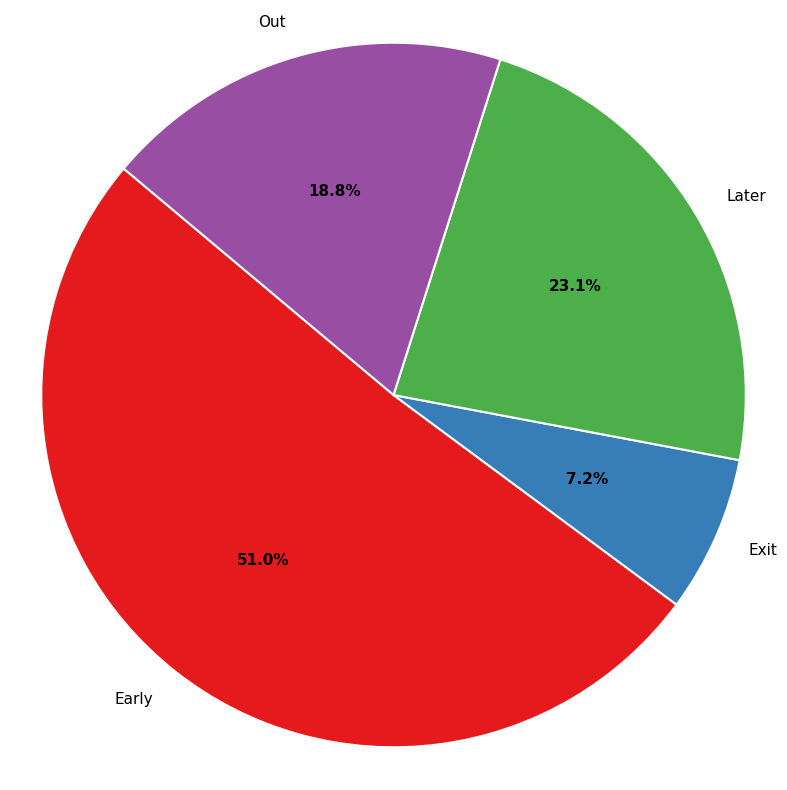

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calcolo delle frequenze direttamente dal dataset
target_counts = df_target_final['Target'].value_counts()

# Estraiamo etichette e valori in ordine
labels = target_counts["Target"].to_list()
sizes = target_counts["count"].to_list()

# 2. Definizione colori (Palette 'Set1' di Matplotlib, molto simile alla tua immagine)
# Se hai più di 4 categorie, questa palette si adatta automaticamente
colors = plt.get_cmap('Set1').colors

# 3. Creazione del grafico
fig, ax = plt.subplots(figsize=(8, 8))

# autopct calcola la percentuale reale dai dati
patches, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    colors=colors, 
    startangle=140,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
    textprops={'fontsize': 11}
)

# Rendiamo le percentuali interne più leggibili (bianche o nere a seconda del gusto)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')

# 4. Estetica finale
plt.axis('equal') 

plt.tight_layout()
plt.show()

Creazione dataset per la classificazione binaria

In [15]:
dataset = df_target_final.with_columns(
    pl.when(pl.col("Target").is_in(["Later", "Exit"]))
    .then(1)
    .otherwise(0)
    .alias("Target") # Dai un nome alla nuova colonna o usa "Target" per sovrascrivere
)

dataset.write_csv(config['paths']['dataset'])


Correlazione features

In [16]:
dataset = pd.read_csv(config["paths"]["dataset"])
corr_matrix = dataset.drop(['CompanyID', 'Target'],axis=1).corr()


# plt.figure(figsize=(30,20))
# ax = sns.heatmap(data = corr_matrix,cmap='YlGnBu',annot=True)

# bottom, top = ax.get_ylim()
# ax.set_ylim(bottom + 0.5,top - 0.5)


# Trasforma la matrice in una serie di coppie (stack)
# e rimuove i duplicati (unstack della parte superiore della matrice)
sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .reset_index())

sol.columns = ['Variabile_1', 'Variabile_2', 'Correlazione']

# Applica il filtro per i range richiesti
mask = (
    ((sol['Correlazione'] >= 0.90) & (sol['Correlazione'] <= 0.99)) |
    ((sol['Correlazione'] <= -0.90) & (sol['Correlazione'] >= -0.99))
)

risultato = sol[mask].sort_values(by='Correlazione', ascending=False)

print(risultato)





Empty DataFrame
Columns: [Variabile_1, Variabile_2, Correlazione]
Index: []


In [17]:
import os
import wandb
import xgboost as xgb
import lightgbm as lgb

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler


from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import shap
import matplotlib.pyplot as plt # Necessario per salvare i grafici
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


dataset = pd.read_csv(config["paths"]["dataset"])

entity=os.getenv("entity")
project=os.getenv("project")

# Inizializza lo sweep
sweep_id = wandb.sweep(config["sweep_settings"],entity=entity, project=project)


/home/giulio-casti/Scrivania/UNICA/DOTTORATO/startup-survival/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/giulio-casti/.netrc.


Create sweep with ID: e34no2s1
Sweep URL: https://wandb.ai/giuliocasti-universit-degli-studi-di-cagliari/startup-prediction-exp3/sweeps/e34no2s1


In [18]:
ids = dataset['CompanyID']  # Salva la colonna ID
X = dataset.drop(['CompanyID', 'Target'],axis=1)
y = dataset['Target']

worst_features = []

# Split: 60% train, 20% test (threshold tuning), 20% validation (final evaluation)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=config['test_size'], stratify=y, random_state=config['random_seed'])
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=config['random_seed'])


imputer = SimpleImputer(strategy='mean')#median

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)
X_val_imp = imputer.transform(X_val)



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)
X_val_scaled = scaler.transform(X_val_imp)

# --- SMOTE ---
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)


print(f"Train: {len(y_train)} | Train resampled: {len(y_res)} | Test (threshold): {len(y_test)} | Validation (eval): {len(y_val)}")

def find_best_threshold(y_true, probs):
    """Trova la soglia che massimizza l'F1 score"""
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_t, best_f1 = 0.5, 0
    for t in thresholds:
        preds_t = (probs >= t).astype(int)
        f1_t = f1_score(y_true, preds_t, zero_division=0)
        if f1_t > best_f1:
            best_f1 = f1_t
            best_t = t
    return best_t, best_f1

def train():
    with wandb.init():
        wandb_config = wandb.config
        
        # --- RANDOM FOREST ---
        if wandb_config.model_type == "rf":
            model = RandomForestClassifier(
                n_estimators=wandb_config.n_estimators,
                max_depth=wandb_config.max_depth, 
                min_samples_leaf=wandb_config.min_samples_leaf,
                max_features='log2',
                # min_samples_split=wandb_config.min_samples_split,
                class_weight='balanced',  
                random_state=config['random_seed']
            )

            # Usa dati undersampled per RF
            model.fit(X_train, y_train)
            probs_test = model.predict_proba(X_test)[:, 1]
            probs_val = model.predict_proba(X_val)[:, 1]
            probs_train = model.predict_proba(X_train)[:, 1]

        # --- LGBM ---
        elif wandb_config.model_type == "lgb":
            # Calcolo del rapporto per scale_pos_weight (80/20 -> 4)
            ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1]) 
            
            model = lgb.LGBMClassifier(
                n_estimators=wandb_config.n_estimators, 
                learning_rate=wandb_config.learning_rate,
                max_depth=wandb_config.max_depth,
                scale_pos_weight=ratio,  
                min_child_weight=wandb_config.min_child_weight, 
                subsample=wandb_config.subsample,               
                colsample_bytree=wandb_config.colsample_bytree,
                reg_alpha=wandb_config.reg_alpha,
                reg_lambda=wandb_config.reg_lambda,
                random_state=config['random_seed']
            )

            # Usa dati undersampled per LGBM
            model.fit(X_train, y_train)
            probs_test = model.predict_proba(X_test)[:, 1]
            probs_val = model.predict_proba(X_val)[:, 1]
            probs_train = model.predict_proba(X_train)[:, 1]

        elif wandb_config.model_type == "mlp":
            model = MLPClassifier(
                hidden_layer_sizes=wandb_config.hidden_layer_sizes,
                activation='relu',
                solver='adam',
                alpha=wandb_config.alpha,
                learning_rate_init=wandb_config.learning_rate_init,
                random_state=config['random_seed'],
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10
            )
           
            # Usiamo i dati ricampionati (X_res, y_res)
            model.fit(X_res, y_res)
            probs_test = model.predict_proba(X_test_scaled)[:, 1]
            probs_val = model.predict_proba(X_val_scaled)[:, 1]
            probs_train = model.predict_proba(X_train_scaled)[:, 1]
        

        # Trova la soglia ottimale sul test set
        best_threshold, best_f1_test = find_best_threshold(y_test, probs_test)

        # Applica la soglia ottimale al validation set
        preds_val = (probs_val >= best_threshold).astype(int)
        preds_train = (probs_train >= best_threshold).astype(int)

        # Metriche sul validation set
        acc = accuracy_score(y_val, preds_val)
        acc_train = accuracy_score(y_train, preds_train)
        precision = precision_score(y_val, preds_val, zero_division=0)
        recall = recall_score(y_val, preds_val, zero_division=0)
        f1 = f1_score(y_val, preds_val, zero_division=0)
        f1_train = f1_score(y_train, preds_train, zero_division=0)

        # ROC Curve (validation set)
        fpr, tpr, _ = roc_curve(y_val, probs_val)
        roc_auc = auc(fpr, tpr)

        fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
        ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        ax_roc.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC - {wandb_config.model_type.upper()}')
        ax_roc.legend(loc='lower right')
        ax_roc.grid(alpha=0.3)

        # Precision-Recall Curve (validation set)
        prec_curve, rec_curve, _ = precision_recall_curve(y_val, probs_val)
        ap = average_precision_score(y_val, probs_val)

        fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
        ax_pr.plot(rec_curve, prec_curve, color='green', lw=2, label=f'PR curve (AP = {ap:.3f})')
        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.set_title(f'Precision-Recall - {wandb_config.model_type.upper()}')
        ax_pr.legend(loc='upper right')
        ax_pr.grid(alpha=0.3)

        # Log delle metriche
        wandb.log({
            "accuracy_train": acc_train,
            "F1_train": f1_train,
            "accuracy": acc,
            "F1": f1,
            "precision": precision,
            "recall": recall,
            "AUC": roc_auc,
            "average_precision": ap,
            "best_threshold": best_threshold,
            "F1_test_at_threshold": best_f1_test,
            "roc_curve": wandb.Image(fig_roc),
            "pr_curve": wandb.Image(fig_pr),
        })
        plt.close(fig_roc)
        plt.close(fig_pr)

        print(f"Best threshold (test set): {best_threshold:.2f} | F1 test: {best_f1_test:.3f}")
        print(f"\nValidation set results (threshold={best_threshold:.2f}):")
        print(classification_report(y_val, preds_val))
        print(f"AUC: {roc_auc:.3f} | AP: {ap:.3f}")


        wandb.sklearn.plot_confusion_matrix(y_val, preds_val, ["Neg", "Pos"])
        if(True):
            # Dati coerenti con il modello usato
            if wandb_config.model_type in ["rf", "lgb"]:
                explainer_sample = X_test.iloc[:1000]          # non scaled — RF e LGBM fittati su X_train
            else:
                explainer_sample = X_test_scaled[:1000]         # scaled — MLP fittato su X_res (scaled)

            if wandb_config.model_type in ["rf", "lgb"]:      # ← aggiunto "lgb"
                explainer = shap.TreeExplainer(model)
                shap_result = explainer.shap_values(explainer_sample)

                # LGBM e RF moderni restituiscono array 3D (n_samples, n_features, n_classes)
                # oppure lista [classe_0, classe_1] — gestiamo entrambi
                if isinstance(shap_result, list):
                    shap_values = shap_result[1]
                elif hasattr(shap_result, 'shape') and len(shap_result.shape) == 3:
                    shap_values = shap_result[:, :, 1]
                else:
                    shap_values = shap_result

            else:
                # MLP — KernelExplainer
                background = shap.sample(X_res, 30)            # background da dati scaled (coerente con MLP)
                explainer = shap.KernelExplainer(
                    lambda x: model.predict_proba(x)[:, 1],    # solo classe 1 → output 1D, più stabile
                    background
                )
                shap_values = explainer.shap_values(explainer_sample, nsamples=1000)
                # KernelExplainer con output 1D restituisce già un array 2D — nessuna gestione extra

            # Summary plot — uguale per tutti
            plt.figure(figsize=(10, 6))
            shap.summary_plot(
                shap_values,
                explainer_sample,
                feature_names=X.columns.tolist(),
                show=False
            )
            wandb.log({"shap_summary_plot": wandb.Image(plt)})
            plt.close()

            # Le 10 feature meno importanti secondo SHAP
            mean_abs_shap = np.abs(shap_values).mean(axis=0)

            shap_importance = pd.DataFrame({
                'feature': X.columns.tolist(),
                'importance': mean_abs_shap
            }).sort_values('importance', ascending=True)  # ascending=True → le peggiori prime

            bottom_10 = shap_importance.head(10)['feature'].tolist()
            worst_features.extend(bottom_10)  # Salva le feature da rimuovere per eventuali iterazioni future
            print("Feature da rimuovere:", bottom_10)

        # perm_importance = permutation_importance(model, X_test_scaled, y_test, scoring='accuracy', random_state=config['random_seed'])


        # sorted_importances_idx = perm_importance.importances_mean.argsort()[::-1]
        
        # # top_30_names = [X.columns[i] for i in sorted_importances_idx[:30]]
        


        # # # 2. Log come stringa unica su W&B (così appare nei grafici e nei log)
        # # top_30_str = "['"+"', '".join(top_30_names)+"']"
        # # wandb.log({"top_features_text": top_30_str})

        # importances = pd.DataFrame(
        #     perm_importance.importances[sorted_importances_idx].T,
        #     columns=X.columns[sorted_importances_idx],
        # )

        #     # Calcola l'altezza dinamica in base al numero di feature
        # fig_height = len(X.columns) * 0.3 
        # fig, ax = plt.subplots(figsize=(10, fig_height))

        # importances.plot.box(vert=False, whis=10, ax=ax)
        # ax.set_title("Permutation Importances (test set)")
        # ax.axvline(x=0, color="r", linestyle="--", alpha=0.5)
        # ax.set_xlabel("Diminuzione della performance")
        # plt.tight_layout()

        # # Log su W&B
        # wandb.log({"permutation_importance_plot": wandb.Image(plt)})
        # plt.close(fig) # Chiudi la figura per liberare memoria

Train: 19590 | Train resampled: 27332 | Test (threshold): 6530 | Validation (eval): 6530


In [ ]:
print(list(set(worst_features)))

In [19]:
wandb.agent(sweep_id, function=train, count=20)

wandb: Agent Starting Run: 6lx87q9t with config:
wandb: 	activation: tanh
wandb: 	alpha: 0.0006029521908015217
wandb: 	colsample_bytree: 0.4
wandb: 	hidden_layer_sizes: [64, 32]
wandb: 	learning_rate: 0.010522857725443358
wandb: 	learning_rate_init: 0.002455182190302481
wandb: 	max_depth: 3
wandb: 	min_child_weight: 20
wandb: 	min_samples_leaf: 5
wandb: 	model_type: mlp
wandb: 	n_estimators: 100
wandb: 	reg_alpha: 1.136324409355581
wandb: 	reg_lambda: 3.830425687120315
wandb: 	solver: adam
wandb: 	subsample: 0.6
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/giulio-casti/.netrc.
wandb: Currently logged in as: giuliocasti (giuliocasti-universit-degli-studi-di-cagliari) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Best threshold (test set): 0.25 | F1 test: 0.548

Validation set results (threshold=0.25):
              precision    recall  f1-score   support

           0       0.83      0.59      0.69      4555
           1       0.43      0.71      0.54      1975

    accuracy                           0.63      6530
   macro avg       0.63      0.65      0.61      6530
weighted avg       0.71      0.63      0.64      6530

AUC: 0.712 | AP: 0.535


100%|██████████| 1000/1000 [01:05<00:00, 15.32it/s]


Feature da rimuovere: ['Is_Debt', 'has_PrivateEquity_Lead', 'TotalRaised_Est', 'has_Corporate_Lead', 'has_Angel_Lead', 'Is_SpinOff', 'has_PrivateEquity', 'has_PublicInvestor_Lead', 'Is_SS', 'Is_Law']


AUC,▁
F1,▁
F1_test_at_threshold,▁
F1_train,▁
accuracy,▁
accuracy_train,▁
average_precision,▁
best_threshold,▁
precision,▁
recall,▁
AUC,0.71193


...

wandb: Agent Starting Run: 2zj5yws1 with config:
wandb: 	activation: relu
wandb: 	alpha: 0.056603434067870766
wandb: 	colsample_bytree: 0.8
wandb: 	hidden_layer_sizes: [64, 32]
wandb: 	learning_rate: 0.03266048852109404
wandb: 	learning_rate_init: 0.0028306184663724637
wandb: 	max_depth: 7
wandb: 	min_child_weight: 5
wandb: 	min_samples_leaf: 9
wandb: 	model_type: lgb
wandb: 	n_estimators: 100
wandb: 	reg_alpha: 7.283310872139183
wandb: 	reg_lambda: 1.129175385855913
wandb: 	solver: sgd
wandb: 	subsample: 0.6
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/giulio-casti/.netrc.


[LightGBM] [Info] Number of positive: 5924, number of negative: 13666
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003865 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2078
[LightGBM] [Info] Number of data points in the train set: 19590, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.302399 -> initscore=-0.835899
[LightGBM] [Info] Start training from score -0.835899
Best threshold (test set): 0.49 | F1 test: 0.624

Validation set results (threshold=0.49):
              precision    recall  f1-score   support

           0       0.86      0.73      0.79      4555
           1       0.53      0.72      0.61      1975

    accuracy                           0.72      6530
   macro avg       0.69      0.72      0.70      6530
weighted avg       0.76      0.72      0.73      6530

AUC: 0.800 | AP: 0.632


/home/giulio-casti/Scrivania/UNICA/DOTTORATO/startup-survival/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Feature da rimuovere: ['Is_Law', 'Is_Debt', 'Is_SS', 'has_PublicInvestor_Lead', 'has_Corporate_Lead', 'has_PrivateEquity_Lead', 'has_Angel_Lead', 'Is_SpinOff', 'has_PrivateEquity', 'Gender_CEO_Female']


AUC,▁
F1,▁
F1_test_at_threshold,▁
F1_train,▁
accuracy,▁
accuracy_train,▁
average_precision,▁
best_threshold,▁
precision,▁
recall,▁
AUC,0.8003


Epoch   1 | Train Loss: 0.5819 | Val Loss: 0.5673 | Val AUC: 0.7807 | Val F1: 0.5910
Epoch   2 | Train Loss: 0.5703 | Val Loss: 0.5704 | Val AUC: 0.7841 | Val F1: 0.5908
Epoch   3 | Train Loss: 0.5666 | Val Loss: 0.5747 | Val AUC: 0.7823 | Val F1: 0.5940
Epoch   4 | Train Loss: 0.5644 | Val Loss: 0.5802 | Val AUC: 0.7802 | Val F1: 0.5969
Epoch   5 | Train Loss: 0.5633 | Val Loss: 0.5805 | Val AUC: 0.7848 | Val F1: 0.5974
Epoch   6 | Train Loss: 0.5614 | Val Loss: 0.6224 | Val AUC: 0.7830 | Val F1: 0.5893
Epoch   7 | Train Loss: 0.5596 | Val Loss: 0.5754 | Val AUC: 0.7808 | Val F1: 0.5916
Epoch   8 | Train Loss: 0.5576 | Val Loss: 0.5795 | Val AUC: 0.7858 | Val F1: 0.5942
Epoch   9 | Train Loss: 0.5568 | Val Loss: 0.5629 | Val AUC: 0.7837 | Val F1: 0.5967
Epoch  10 | Train Loss: 0.5551 | Val Loss: 0.5875 | Val AUC: 0.7841 | Val F1: 0.5935
Epoch  11 | Train Loss: 0.5552 | Val Loss: 0.5750 | Val AUC: 0.7853 | Val F1: 0.5990
Epoch  12 | Train Loss: 0.5551 | Val Loss: 0.5763 | Val AUC: 0.78

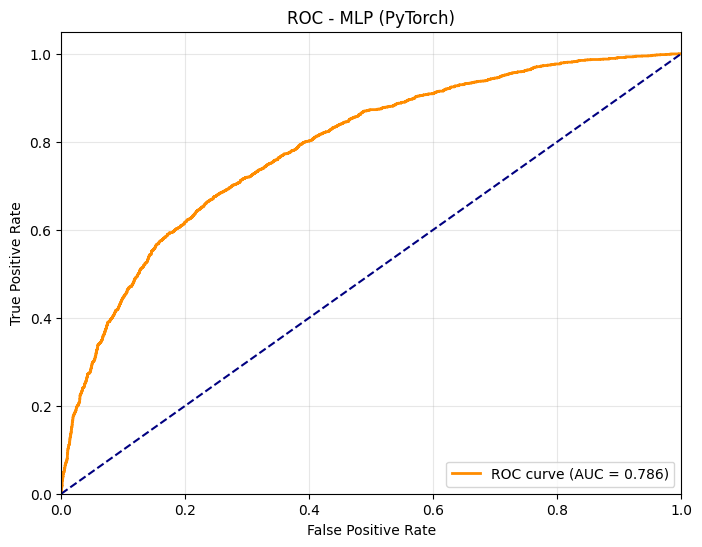

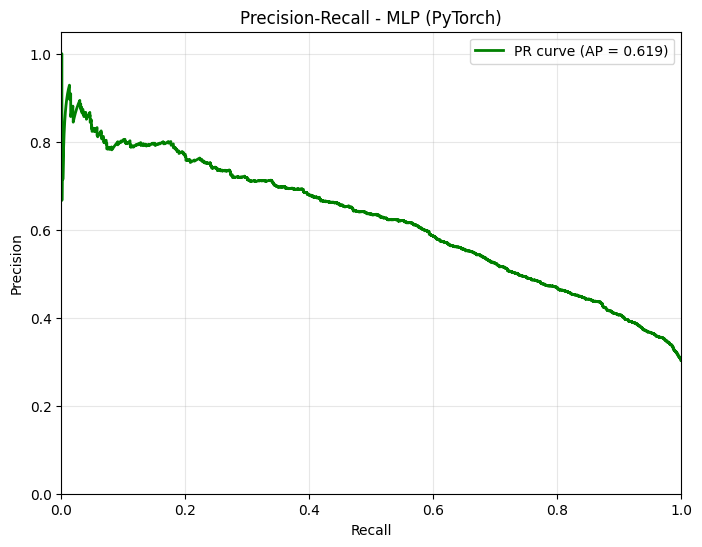

Best threshold (test set, F2, min_acc=0.75): 0.60 | F2 test: 0.615

Validation set results (threshold=0.60):
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      4555
           1       0.57      0.61      0.59      1975

    accuracy                           0.75      6530
   macro avg       0.70      0.71      0.70      6530
weighted avg       0.75      0.75      0.75      6530

Accuracy train: 0.755 | F1 train: 0.612
Accuracy: 0.745 | Precision: 0.573 | Recall: 0.614 | F1: 0.593 | F2: 0.606
AUC: 0.786 | AP: 0.619


In [20]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (accuracy_score, f1_score, fbeta_score, precision_score, recall_score,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
from src.models.MLP import MLP


# ── 1. PREPROCESSING ─────────────────────
imputer_mlp = KNNImputer(n_neighbors=5)
X_train_mlp = imputer_mlp.fit_transform(X_train)
X_val_mlp   = imputer_mlp.transform(X_val)
X_test_mlp  = imputer_mlp.transform(X_test)

scaler_mlp = RobustScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train_mlp)
X_val_mlp   = scaler_mlp.transform(X_val_mlp)
X_test_mlp  = scaler_mlp.transform(X_test_mlp)

# --- SMOTE sul training set (bilancia le classi, no pos_weight necessario) ---
smote_mlp = SMOTE(random_state=42)
X_train_res, y_train_res = smote_mlp.fit_resample(X_train_mlp, y_train)

# ── 2. CONVERSIONE IN TENSORI ─────────────
def to_tensors(X, y):
    y_np = y.values if hasattr(y, 'values') else y
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)
    )

X_train_t, y_train_t = to_tensors(X_train_res, y_train_res)
X_val_t,   y_val_t   = to_tensors(X_val_mlp,   y_val)
X_test_t,  y_test_t  = to_tensors(X_test_mlp,  y_test)

# Tensori del train originale (senza SMOTE) per valutazione
X_train_orig_t, y_train_orig_t = to_tensors(X_train_mlp, y_train)

# ── 3. DATALOADER ─────────────────────────
BATCH_SIZE = 256

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                          batch_size=BATCH_SIZE)

# ── 4. MODELLO, LOSS, OPTIMIZER ───────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mlp_model = MLP(
    input_size=X_train_mlp.shape[1],
    hidden_sizes=[256, 128, 64],
    dropout_rate=0.3,
    batch_norm=True
).to(device)

# SMOTE bilancia i dati → loss senza pos_weight
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

# ── 5. TRAINING LOOP ──────────────────────
EPOCHS = 100
best_auc = 0.0
patience_counter = 0
EARLY_STOPPING_PATIENCE = 10

for epoch in range(EPOCHS):

    # ── Train ──
    mlp_model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = mlp_model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(X_batch)

    train_loss /= len(train_loader.dataset)

    # ── Validation ──
    mlp_model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = mlp_model(X_batch)
            loss   = criterion(logits, y_batch)
            val_loss += loss.item() * len(X_batch)

            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_auc   = roc_auc_score(all_labels, all_preds)
    val_f1    = f1_score(all_labels, (np.array(all_preds) > 0.5).astype(int))

    scheduler.step(val_auc)

    print(f"Epoch {epoch+1:3d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val AUC: {val_auc:.4f} | "
          f"Val F1: {val_f1:.4f}")

    # ── Early Stopping + Best Model ──
    if val_auc > best_auc:
        best_auc = val_auc
        patience_counter = 0
        torch.save(mlp_model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}. Best AUC: {best_auc:.4f}")
            break

# ── 6. VALUTAZIONE ────────────────────────
mlp_model.load_state_dict(torch.load("best_model.pt", weights_only=True))
mlp_model.eval()

def get_probs(loader):
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = mlp_model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_batch.numpy())
    return np.array(all_probs).flatten(), np.array(all_labels).flatten().astype(int)

# Threshold tuning con F2 + vincolo di accuracy minima
def find_best_threshold_f2(y_true, probs, beta=2, min_accuracy=0.75):
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_t, best_score = 0.5, 0
    for t in thresholds:
        preds_t = (probs >= t).astype(int)
        acc_t = accuracy_score(y_true, preds_t)
        if acc_t < min_accuracy:
            continue
        score = fbeta_score(y_true, preds_t, beta=beta, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = t
    return best_t, best_score

# Loader senza shuffle per il train originale (senza SMOTE)
train_eval_loader = DataLoader(TensorDataset(X_train_orig_t, y_train_orig_t),
                               batch_size=BATCH_SIZE, shuffle=False)

probs_train, labels_train = get_probs(train_eval_loader)
probs_test,  labels_test  = get_probs(test_loader)
probs_val,   labels_val   = get_probs(val_loader)

# Threshold tuning sul test set con F2 (accuracy >= 0.75)
best_threshold, best_f2_test = find_best_threshold_f2(labels_test, probs_test, beta=2, min_accuracy=0.75)

# Applicazione soglia ottimale
preds_val   = (probs_val   >= best_threshold).astype(int)
preds_train = (probs_train >= best_threshold).astype(int)

# Metriche sul validation set
acc       = accuracy_score(labels_val, preds_val)
acc_train = accuracy_score(labels_train, preds_train)
precision = precision_score(labels_val, preds_val, zero_division=0)
recall    = recall_score(labels_val, preds_val, zero_division=0)
f1        = f1_score(labels_val, preds_val, zero_division=0)
f2        = fbeta_score(labels_val, preds_val, beta=2, zero_division=0)
f1_train  = f1_score(labels_train, preds_train, zero_division=0)

# ROC Curve (validation set)
fpr, tpr, _ = roc_curve(labels_val, probs_val)
roc_auc = auc(fpr, tpr)

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC - MLP (PyTorch)')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

# Precision-Recall Curve (validation set)
prec_curve, rec_curve, _ = precision_recall_curve(labels_val, probs_val)
ap = average_precision_score(labels_val, probs_val)

fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
ax_pr.plot(rec_curve, prec_curve, color='green', lw=2, label=f'PR curve (AP = {ap:.3f})')
ax_pr.set_xlim([0.0, 1.0])
ax_pr.set_ylim([0.0, 1.05])
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall - MLP (PyTorch)')
ax_pr.legend(loc='upper right')
ax_pr.grid(alpha=0.3)

plt.show()

print(f"Best threshold (test set, F2, min_acc=0.75): {best_threshold:.2f} | F2 test: {best_f2_test:.3f}")
print(f"\nValidation set results (threshold={best_threshold:.2f}):")
print(classification_report(labels_val, preds_val))
print(f"Accuracy train: {acc_train:.3f} | F1 train: {f1_train:.3f}")
print(f"Accuracy: {acc:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f} | F2: {f2:.3f}")
print(f"AUC: {roc_auc:.3f} | AP: {ap:.3f}")


RELU
Best threshold (test set): 0.64 | F1 test: 0.494

Validation set results (threshold=0.64):
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      7412
           1       0.47      0.50      0.48      1621

    accuracy                           0.81      9033
   macro avg       0.68      0.69      0.68      9033
weighted avg       0.81      0.81      0.81      9033

Accuracy train: 0.825 | F1 train: 0.524
Accuracy: 0.808 | Precision: 0.466 | Recall: 0.497 | F1: 0.481
AUC: 0.788 | AP: 0.486


TANH
Best threshold (test set): 0.69 | F1 test: 0.493

Validation set results (threshold=0.69):
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      7412
           1       0.50      0.46      0.48      1621

    accuracy                           0.82      9033
   macro avg       0.69      0.68      0.68      9033
weighted avg       0.81      0.82      0.82      9033

Accuracy train: 0.828 | F1 train: 0.508
Accuracy: 0.819 | Precision: 0.496 | Recall: 0.456 | F1: 0.475
AUC: 0.785 | AP: 0.488




Best threshold (test set, F2, min_acc=0.7): 0.48 | F2 test: 0.600

Validation set results (threshold=0.48):
              precision    recall  f1-score   support

           0       0.92      0.70      0.80      7412
           1       0.34      0.71      0.46      1621

    accuracy                           0.70      9033
   macro avg       0.63      0.71      0.63      9033
weighted avg       0.81      0.70      0.74      9033

Accuracy train: 0.721 | F1 train: 0.495
Accuracy: 0.704 | Precision: 0.343 | Recall: 0.713 | F1: 0.463 | F2: 0.586
AUC: 0.781 | AP: 0.479


Best threshold (test set, F2, min_acc=0.75): 0.61 | F2 test: 0.558

Validation set results (threshold=0.61):
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      7412
           1       0.39      0.60      0.47      1621

    accuracy                           0.76      9033
   macro avg       0.64      0.70      0.66      9033
weighted avg       0.81      0.76      0.78      9033

Accuracy train: 0.774 | F1 train: 0.514
Accuracy: 0.757 | Precision: 0.386 | Recall: 0.604 | F1: 0.471 | F2: 0.543
AUC: 0.782 | AP: 0.480